## Regression Model With Pytorch Componentes

1. Data gathering
2. Data preprocessing
3. feature engineering
4. Model Training
5. Testing


Data set used :- https://www.kaggle.com/datasets/mirichoi0218/insurance

In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import torch
import torch.nn as nn
import  torch.optim as optim
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

In [3]:
df = pd.read_csv('insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [5]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


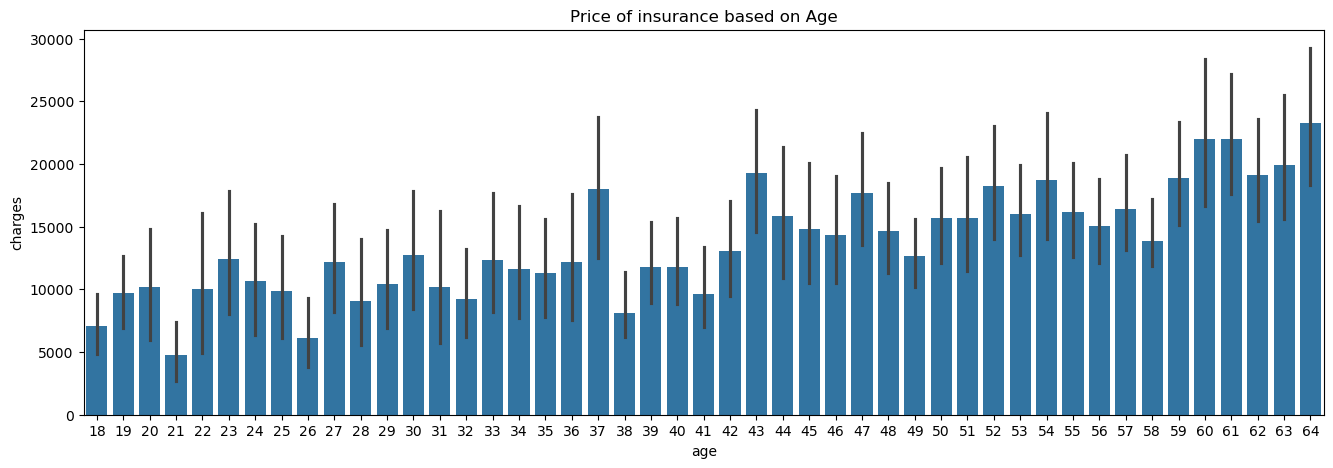

In [6]:
plt.figure(figsize=(16 ,5))
sns.barplot(data=df, x='age', y='charges')
plt.title("Price of insurance based on Age")
plt.show()

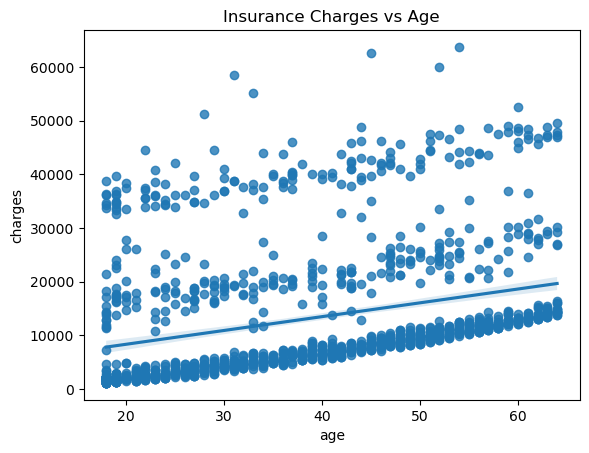

In [7]:
sns.regplot(data=df, x='age', y='charges')
plt.title("Insurance Charges vs Age")
plt.show()

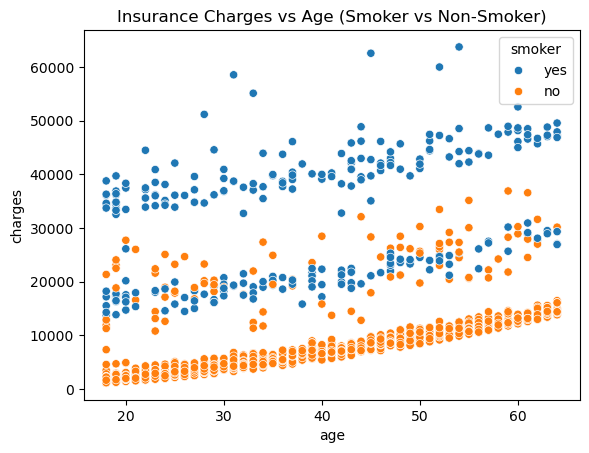

In [8]:
sns.scatterplot(data=df, x='age', y='charges', hue='smoker')
plt.title("Insurance Charges vs Age (Smoker vs Non-Smoker)")
plt.show()

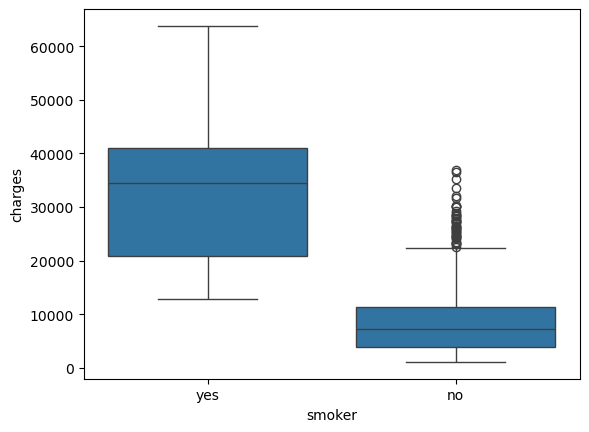

In [9]:
sns.boxplot(data=df, x='smoker', y='charges')
plt.show()

In [10]:
# Split dataset before encodeing
train_df, test_df = train_test_split(df,test_size=0.02,random_state=42)

In [11]:
## Encode  categorical variable

label_encoder = {}

for col in  ["sex","smoker","region"]:
    le = LabelEncoder()
    train_df[col]=  le.fit_transform(train_df[col])
    test_df[col]=  le.transform(test_df[col])
    label_encoder[col] = le

In [12]:
# Features and target 
X_train= train_df.drop(columns=['charges'])
y_train = train_df['charges']

X_test = test_df.drop(columns=['charges'])
y_test = test_df['charges']


In [13]:
X_train.head()

,age,sex,bmi,children,smoker,region
429,27,0,30.400,3,0,1
275,47,0,26.600,2,0,0
808,18,1,30.140,0,0,2
1253,40,0,29.300,4,0,3
765,57,0,31.825,0,0,1


In [14]:
X_test.head()

,age,sex,bmi,children,smoker,region
764,45,0,25.175,2,0,0
887,36,0,30.020,0,0,1
890,64,0,26.885,0,1,1
1293,46,1,25.745,3,0,1
259,19,1,31.920,0,1,1


In [15]:
## Normalize features

scaler =  StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [16]:
# Convert to tensore

X_train_tensor = torch.tensor(X_train,dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values,dtype=torch.float32).view(-1,1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1,1)

In [17]:
# Define Neural Network model

class SimpleNNRegressionModel(nn.Module):
    def __init__(self,input_dim):
        super(SimpleNNRegressionModel,self).__init__()
        
        self.network = nn.Sequential(
        nn.Linear(input_dim,64),
        nn.ReLU(),
        nn.Linear(64,128),
        nn.ReLU(),
        nn.Linear(128,1)
        )
    def forward(self,x):
        return self.network(x)
        

In [18]:
input_dim = X_train_tensor.shape[1]
model = SimpleNNRegressionModel(input_dim)

In [19]:
print(model)

SimpleNNRegressionModel(
  (network): Sequential(
    (0): Linear(in_features=6, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=1, bias=True)
  )
)


In [20]:
## Loss & optimizer

criterion = nn.MSELoss()
optimiser = optim.Adam(model.parameters(),lr= 0.01)


In [21]:
## Training loops
epoch = 30000

for e in range(epoch):
    model.train()
    optimiser.zero_grad()
    prediction = model(X_train_tensor) 
    loss = criterion(prediction,y_train_tensor)
    loss.backward()
    optimiser.step()
    
    if (e+1) % 100 ==0 :
        print(f"Epoch[{e+1}]/50, Loss: {loss.item():.4f}")
       

Epoch[100]/50, Loss: 45773692.0000
Epoch[200]/50, Loss: 31691348.0000
Epoch[300]/50, Loss: 29013608.0000
Epoch[400]/50, Loss: 27085108.0000
Epoch[500]/50, Loss: 25989798.0000
Epoch[600]/50, Loss: 25215736.0000
Epoch[700]/50, Loss: 24614070.0000
Epoch[800]/50, Loss: 24096606.0000
Epoch[900]/50, Loss: 23667448.0000
Epoch[1000]/50, Loss: 23356538.0000
Epoch[1100]/50, Loss: 23121824.0000
Epoch[1200]/50, Loss: 22938100.0000
Epoch[1300]/50, Loss: 22794042.0000
Epoch[1400]/50, Loss: 22681610.0000
Epoch[1500]/50, Loss: 22590954.0000
Epoch[1600]/50, Loss: 22509314.0000
Epoch[1700]/50, Loss: 22436466.0000
Epoch[1800]/50, Loss: 22341980.0000
Epoch[1900]/50, Loss: 22221066.0000
Epoch[2000]/50, Loss: 22083110.0000
Epoch[2100]/50, Loss: 21968682.0000
Epoch[2200]/50, Loss: 21854238.0000
Epoch[2300]/50, Loss: 21751454.0000
Epoch[2400]/50, Loss: 21616730.0000
Epoch[2500]/50, Loss: 21354106.0000
Epoch[2600]/50, Loss: 20936074.0000
Epoch[2700]/50, Loss: 20496198.0000
Epoch[2800]/50, Loss: 19970912.0000
E

In [22]:
## Model Evaluation 

model.eval()
y_pred = model(X_test_tensor).detach().numpy()

In [23]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y_test_numpy = y_test_tensor.numpy()
## Calculate metrics
mse = mean_squared_error(y_test_numpy, y_pred)
rmse = mse ** 0.5
mae = mean_absolute_error(y_test_numpy,y_pred)
r2 = r2_score(y_test_numpy,y_pred)

print(f"MSE:{mse}")
print(f"RMSE:{rmse}")
print(f"MAE:{mae}")
print(f"R2-score:{r2}")

MSE:18466856.0
RMSE:4297.307994547284
MAE:3154.55322265625
R2-score:0.9127339124679565


In [24]:
def predict_charges(age, sex, bmi, children, smoker, region):

    input_data = pd.DataFrame([[age, sex, bmi, children, smoker, region]],
                              columns=['age','sex','bmi','children','smoker','region'])

    for col in ["sex","smoker","region"]:
        input_data[col] = label_encoder[col].transform(input_data[col])

    input_data = scaler.transform(input_data)

    input_tensor = torch.tensor(input_data, dtype=torch.float32)

    prediction = model(input_tensor).item()

    return prediction

In [25]:
predicted = predict_charges(28, 'female', 27.9, 5, 'no', 'southwest')

print(f"Predicted insurance charge: ${predicted:.2f}")

Predicted insurance charge: $-2627.59


In [26]:
torch.save(model.state_dict(),"insurance_model.path")

# Understanding Components of a Custom DataLoader in Pytorch

1. Dataset(torch.utils.data.Dataset)
2. DataLoader (torch.utils.data.Dataloader) ## it will rap the data set 


In [27]:
# Creating our Custom Dataset in pytorch
# init() - initialised the dataset,loads data, applied preprocessing
# len() -  Return the Total number of row or samples oin the dataset
# getitem() - It defines how to retrieve a single data smaple when an index is provide

In [28]:
import torch 
from torch.utils.data import Dataset,DataLoader

In [29]:
class InsuranceDataset(Dataset):
    
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).view(-1,1)
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [34]:
dataset = InsuranceDataset(X_train, y_train)

dataloader = DataLoader(dataset, batch_size=32, shuffle=True,num_workers=0)

In [35]:
for batch_idx, (features, target) in enumerate(dataloader):

    print(f"Batch : {batch_idx+1}")
    print(f"Features shape : {features.shape}")
    print(f"Targets shape : {target.shape}")

Batch : 1
Features shape : torch.Size([32, 6])
Targets shape : torch.Size([32, 1])
Batch : 2
Features shape : torch.Size([32, 6])
Targets shape : torch.Size([32, 1])
Batch : 3
Features shape : torch.Size([32, 6])
Targets shape : torch.Size([32, 1])
Batch : 4
Features shape : torch.Size([32, 6])
Targets shape : torch.Size([32, 1])
Batch : 5
Features shape : torch.Size([32, 6])
Targets shape : torch.Size([32, 1])
Batch : 6
Features shape : torch.Size([32, 6])
Targets shape : torch.Size([32, 1])
Batch : 7
Features shape : torch.Size([32, 6])
Targets shape : torch.Size([32, 1])
Batch : 8
Features shape : torch.Size([32, 6])
Targets shape : torch.Size([32, 1])
Batch : 9
Features shape : torch.Size([32, 6])
Targets shape : torch.Size([32, 1])
Batch : 10
Features shape : torch.Size([32, 6])
Targets shape : torch.Size([32, 1])
Batch : 11
Features shape : torch.Size([32, 6])
Targets shape : torch.Size([32, 1])
Batch : 12
Features shape : torch.Size([32, 6])
Targets shape : torch.Size([32, 1])
B

In [ ]:
### 1000 --> total  number of data 

# epoch  = 100 
# batch_size = 1
# 1000/1 = 1000
#  Total numbe of eporch = 100epoch * 1000data =  100,000



In [36]:

epoch = 1000

for e in range(epoch):

    model.train()

    for batch_idx, (batch_X, batch_y) in enumerate(dataloader):

        optimiser.zero_grad()

        prediction = model(batch_X)

        loss = criterion(prediction, batch_y)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimiser.step()